In [309]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn 

In [310]:
Emp=pd.read_csv(r'messy_salary_dataset.csv')

In [311]:
Emp

,EmployeeID,YearsExperience,Age,EducationLevel,Department,PerformanceScore,JoinDate,Salary
0,322,6.79,40.30,Bachelor,Sales,3.22,2036-05-14,NaN
1,385,2.72,42.42,High School,Engineering,3.36,2041-07-17,4790606.612324356
2,634,3.72,45.30,Bachelor,Engineering,4.18,2061-12-29,59408.246533400656
3,362,9.60,40.79,Bachelor,Marketing,2.17,2039-08-27,71588.55992158898
4,587,3.62,36.76,Bachelor,Engineering,2.99,NaN,66096.17280797272
...,...,...,...,...,...,...,...,...
995,287,4.54,18.00,Bachelor,Marketing,3.95,2033-06-29,1098624.2228275714
996,376,2.70,32.91,High School,Marketing,3.36,invalid,42161.823950803424
997,617,5.33,37.99,High School,Engineering,3.49,2060-08-06,74673.48386829854
998,103,3.97,55.88,Bachelor,HR,4.22,2018-05-19,67478.03973016735


In [312]:
Emp.shape

(1000, 8)

In [313]:
Emp.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   EmployeeID        1000 non-null   int64  
 1   YearsExperience   953 non-null    float64
 2   Age               945 non-null    float64
 3   EducationLevel    957 non-null    object 
 4   Department        921 non-null    object 
 5   PerformanceScore  945 non-null    float64
 6   JoinDate          979 non-null    object 
 7   Salary            960 non-null    object 
dtypes: float64(3), int64(1), object(4)
memory usage: 62.6+ KB


In [314]:
Emp.describe()

,EmployeeID,YearsExperience,Age,PerformanceScore
count,1000.00,953.00,945.00,945.00
mean,500.30,5.05,42.86,2.94
std,288.80,2.84,83.26,0.96
min,1.00,0.00,-5.00,1.00
25%,250.75,2.97,28.94,2.26
50%,500.50,5.06,35.88,2.99
75%,750.25,6.92,42.59,3.59
max,1000.00,16.56,999.00,5.00


In [315]:
Emp.isnull().sum()

EmployeeID           0
YearsExperience     47
Age                 55
EducationLevel      43
Department          79
PerformanceScore    55
JoinDate            21
Salary              40
dtype: int64

In [316]:
Emp.head()

,EmployeeID,YearsExperience,Age,EducationLevel,Department,PerformanceScore,JoinDate,Salary
0,322,6.79,40.30,Bachelor,Sales,3.22,2036-05-14,NaN
1,385,2.72,42.42,High School,Engineering,3.36,2041-07-17,4790606.612324356
2,634,3.72,45.30,Bachelor,Engineering,4.18,2061-12-29,59408.246533400656
3,362,9.60,40.79,Bachelor,Marketing,2.17,2039-08-27,71588.55992158898
4,587,3.62,36.76,Bachelor,Engineering,2.99,NaN,66096.17280797272


In [317]:
Emp[['Salary','YearsExperience','Age','PerformanceScore']]=Emp[['Salary','YearsExperience','Age','PerformanceScore']].round(2)

In [318]:
Emp

,EmployeeID,YearsExperience,Age,EducationLevel,Department,PerformanceScore,JoinDate,Salary
0,322,6.79,40.30,Bachelor,Sales,3.22,2036-05-14,NaN
1,385,2.72,42.42,High School,Engineering,3.36,2041-07-17,4790606.612324356
2,634,3.72,45.30,Bachelor,Engineering,4.18,2061-12-29,59408.246533400656
3,362,9.60,40.79,Bachelor,Marketing,2.17,2039-08-27,71588.55992158898
4,587,3.62,36.76,Bachelor,Engineering,2.99,NaN,66096.17280797272
...,...,...,...,...,...,...,...,...
995,287,4.54,18.00,Bachelor,Marketing,3.95,2033-06-29,1098624.2228275714
996,376,2.70,32.91,High School,Marketing,3.36,invalid,42161.823950803424
997,617,5.33,37.99,High School,Engineering,3.49,2060-08-06,74673.48386829854
998,103,3.97,55.88,Bachelor,HR,4.22,2018-05-19,67478.03973016735


In [319]:
Emp['Salary'].isnull().sum()

np.int64(40)

In [320]:
Emp['Salary']=Emp['Salary'].dropna()
Emp

,EmployeeID,YearsExperience,Age,EducationLevel,Department,PerformanceScore,JoinDate,Salary
0,322,6.79,40.30,Bachelor,Sales,3.22,2036-05-14,NaN
1,385,2.72,42.42,High School,Engineering,3.36,2041-07-17,4790606.612324356
2,634,3.72,45.30,Bachelor,Engineering,4.18,2061-12-29,59408.246533400656
3,362,9.60,40.79,Bachelor,Marketing,2.17,2039-08-27,71588.55992158898
4,587,3.62,36.76,Bachelor,Engineering,2.99,NaN,66096.17280797272
...,...,...,...,...,...,...,...,...
995,287,4.54,18.00,Bachelor,Marketing,3.95,2033-06-29,1098624.2228275714
996,376,2.70,32.91,High School,Marketing,3.36,invalid,42161.823950803424
997,617,5.33,37.99,High School,Engineering,3.49,2060-08-06,74673.48386829854
998,103,3.97,55.88,Bachelor,HR,4.22,2018-05-19,67478.03973016735


In [321]:
Emp['Salary'].replace([np.nan,'unknown'],0,inplace=True)

C:\Users\bless\AppData\Local\Temp\ipykernel_12484\3105019707.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  Emp['Salary'].replace([np.nan,'unknown'],0,inplace=True)


In [322]:
Emp['Salary'] = Emp['Salary'].astype(str).str.replace(r'[^\d.]', '', regex=True).astype(float)


In [323]:
pd.set_option('display.float_format', '{:.2f}'.format)


In [324]:
Emp.head()

,EmployeeID,YearsExperience,Age,EducationLevel,Department,PerformanceScore,JoinDate,Salary
0,322,6.79,40.30,Bachelor,Sales,3.22,2036-05-14,0.00
1,385,2.72,42.42,High School,Engineering,3.36,2041-07-17,4790606.61
2,634,3.72,45.30,Bachelor,Engineering,4.18,2061-12-29,59408.25
3,362,9.60,40.79,Bachelor,Marketing,2.17,2039-08-27,71588.56
4,587,3.62,36.76,Bachelor,Engineering,2.99,NaN,66096.17


<Axes: xlabel='Salary', ylabel='Count'>

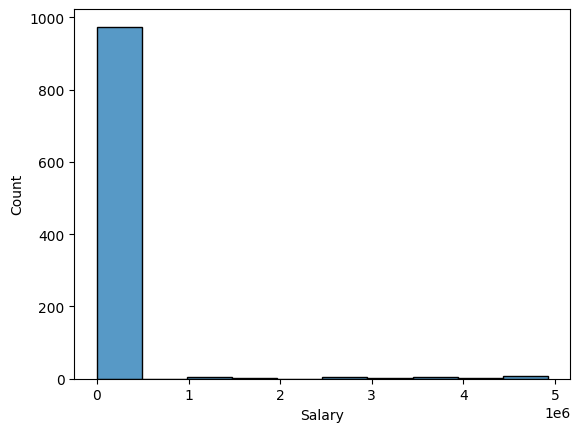

In [325]:
sns.histplot(Emp['Salary'],bins=10)

In [326]:
Emp['Salary'].astype('float')

0           0.00
1     4790606.61
2       59408.25
3       71588.56
4       66096.17
         ...    
995   1098624.22
996     42161.82
997     74673.48
998     67478.04
999     40818.03
Name: Salary, Length: 1000, dtype: float64

In [327]:
Q1=np.percentile(Emp['Salary'],25).round(2)
Q1

np.float64(50552.8)

In [328]:
Q3=np.percentile(Emp['Salary'],75).round(2)
Q3

np.float64(71650.23)

In [329]:
IQR=Q3-Q1
IQR.round(2)

np.float64(21097.43)

In [330]:
Uf=Q3+(1.5*IQR)
LF=Q1-(1.5*IQR)
Uf

np.float64(103296.37499999999)

In [331]:
Emp=Emp[(Emp['Salary']<Uf) & (Emp['Salary']>LF)]
Emp

,EmployeeID,YearsExperience,Age,EducationLevel,Department,PerformanceScore,JoinDate,Salary
2,634,3.72,45.30,Bachelor,Engineering,4.18,2061-12-29,59408.25
3,362,9.60,40.79,Bachelor,Marketing,2.17,2039-08-27,71588.56
4,587,3.62,36.76,Bachelor,Engineering,2.99,NaN,66096.17
5,597,4.19,41.19,Bachelor,NaN,5.00,2058-12-15,63266.36
6,878,5.67,32.91,Master,Marketing,3.42,2082-01-13,52540.96
...,...,...,...,...,...,...,...,...
994,836,5.70,38.62,Bachelor,Engineering,1.87,2078-08-02,52326.68
996,376,2.70,32.91,High School,Marketing,3.36,invalid,42161.82
997,617,5.33,37.99,High School,Engineering,3.49,2060-08-06,74673.48
998,103,3.97,55.88,Bachelor,HR,4.22,2018-05-19,67478.04


In [332]:
Emp['Salary'].isnull().sum()

np.int64(0)

In [333]:
Emp.describe()

,EmployeeID,YearsExperience,Age,PerformanceScore,Salary
count,914.00,869.00,861.00,868.00,914.00
mean,503.89,5.02,41.45,2.95,61658.81
std,288.86,2.76,73.93,0.95,13480.44
min,1.00,0.00,-5.00,1.00,24191.43
25%,255.25,3.05,29.17,2.28,51943.96
50%,508.00,5.07,35.86,3.00,61484.66
75%,753.75,6.90,42.66,3.59,71351.89
max,1000.00,14.24,999.00,5.00,101310.43


In [334]:
Emp['PerformanceScore']=Emp['PerformanceScore'].fillna(0)

C:\Users\bless\AppData\Local\Temp\ipykernel_12484\2419285176.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  Emp['PerformanceScore']=Emp['PerformanceScore'].fillna(0)


In [335]:
Emp['PerformanceScore'].isnull().sum()

np.int64(0)

In [336]:
Emp['PerformanceScore'].isnull().sum()

np.int64(0)

In [337]:
Q1=np.percentile(Emp['PerformanceScore'],25).round(2)
Q1
Q3=np.percentile(Emp['PerformanceScore'],75).round(2)
Q3

np.float64(3.57)

In [338]:
IQR=Q3-Q1
IQR

np.float64(1.4099999999999997)

In [339]:
Ufp=Q3+(1.5*IQR)
Lfp=Q1-(1.5*IQR)
Ufp

np.float64(5.684999999999999)

In [340]:
Clean_emp=Emp.copy()

In [341]:
Clean_emp=Clean_emp[(Clean_emp['PerformanceScore']<Ufp) & (Clean_emp['PerformanceScore']>Lfp)]
Clean_emp

,EmployeeID,YearsExperience,Age,EducationLevel,Department,PerformanceScore,JoinDate,Salary
2,634,3.72,45.30,Bachelor,Engineering,4.18,2061-12-29,59408.25
3,362,9.60,40.79,Bachelor,Marketing,2.17,2039-08-27,71588.56
4,587,3.62,36.76,Bachelor,Engineering,2.99,NaN,66096.17
5,597,4.19,41.19,Bachelor,NaN,5.00,2058-12-15,63266.36
6,878,5.67,32.91,Master,Marketing,3.42,2082-01-13,52540.96
...,...,...,...,...,...,...,...,...
994,836,5.70,38.62,Bachelor,Engineering,1.87,2078-08-02,52326.68
996,376,2.70,32.91,High School,Marketing,3.36,invalid,42161.82
997,617,5.33,37.99,High School,Engineering,3.49,2060-08-06,74673.48
998,103,3.97,55.88,Bachelor,HR,4.22,2018-05-19,67478.04


In [342]:
Clean_emp.describe()

,EmployeeID,YearsExperience,Age,PerformanceScore,Salary
count,868.00,823.00,818.00,868.00,868.00
mean,502.78,5.06,40.56,2.95,61816.98
std,289.91,2.77,68.00,0.95,13456.35
min,1.00,0.00,-5.00,1.00,24191.43
25%,254.75,3.12,29.00,2.28,51984.86
50%,507.50,5.08,35.95,3.00,61568.31
75%,755.25,6.90,42.64,3.59,71588.56
max,1000.00,14.24,999.00,5.00,101310.43


In [343]:
Clean_emp['Age'].isnull().sum()

np.int64(50)

In [344]:
Clean_emp['Age']=Clean_emp['Age'].replace(np.nan,0)


In [345]:
Clean_emp['Age']=Clean_emp['Age'].abs()

In [346]:
Clean_emp['Age'].isnull().sum()

np.int64(0)

In [347]:
Q1=np.percentile(Clean_emp['Age'],25).round(2)
Q3=np.percentile(Clean_emp['Age'],75).round(2)
Q3
Q1

np.float64(27.79)

In [348]:
IQR=Q3-Q1
IQR
Ufa=Q3+(1.5*IQR)
Lfa=Q1-(1.5*IQR)
Lfa

np.float64(6.085000000000001)

In [349]:
Clean_emp=Clean_emp[(Clean_emp['Age']<Ufa) & (Clean_emp['Age']>Lfa)]
Clean_emp

,EmployeeID,YearsExperience,Age,EducationLevel,Department,PerformanceScore,JoinDate,Salary
2,634,3.72,45.30,Bachelor,Engineering,4.18,2061-12-29,59408.25
3,362,9.60,40.79,Bachelor,Marketing,2.17,2039-08-27,71588.56
4,587,3.62,36.76,Bachelor,Engineering,2.99,NaN,66096.17
5,597,4.19,41.19,Bachelor,NaN,5.00,2058-12-15,63266.36
6,878,5.67,32.91,Master,Marketing,3.42,2082-01-13,52540.96
...,...,...,...,...,...,...,...,...
993,482,2.13,31.27,Master,Marketing,2.30,2049-07-05,50928.00
994,836,5.70,38.62,Bachelor,Engineering,1.87,2078-08-02,52326.68
996,376,2.70,32.91,High School,Marketing,3.36,invalid,42161.82
997,617,5.33,37.99,High School,Engineering,3.49,2060-08-06,74673.48


In [350]:
Clean_emp.describe()

,EmployeeID,YearsExperience,Age,PerformanceScore,Salary
count,806.00,763.00,806.00,806.00,806.00
mean,502.88,5.04,36.08,2.95,61855.08
std,288.99,2.78,9.58,0.95,13465.25
min,1.00,0.00,18.00,1.00,24191.43
25%,255.25,3.08,29.17,2.28,52051.42
50%,508.50,5.07,35.95,3.01,61568.31
75%,753.75,6.89,42.54,3.59,71619.61
max,1000.00,14.24,61.44,5.00,101310.43


In [351]:
Clean_emp['YearsExperience'].isnull().sum()

np.int64(43)

In [352]:
Clean_emp['YearsExperience']=Clean_emp['YearsExperience'].replace(np.nan,0)
Clean_emp['YearsExperience']=Clean_emp['YearsExperience'].abs()
Clean_emp['YearsExperience'].isnull().sum()

C:\Users\bless\AppData\Local\Temp\ipykernel_12484\3361572433.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  Clean_emp['YearsExperience']=Clean_emp['YearsExperience'].replace(np.nan,0)
C:\Users\bless\AppData\Local\Temp\ipykernel_12484\3361572433.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  Clean_emp['YearsExperience']=Clean_emp['YearsExperience'].abs()


np.int64(0)

In [353]:
Q1=np.percentile(Clean_emp['YearsExperience'],25).round(2)
Q3=np.percentile(Clean_emp['YearsExperience'],75).round(2)
IQR=Q3-Q1
IQR
Ufe=Q3+(1.5*IQR)
Lfe=Q1-(1.5*IQR)
Lfe

np.float64(-3.6800000000000006)

In [354]:
Clean_emp=Clean_emp[(Clean_emp['YearsExperience']<Ufe) & (Clean_emp['YearsExperience']>Lfe)]
Clean_emp

,EmployeeID,YearsExperience,Age,EducationLevel,Department,PerformanceScore,JoinDate,Salary
2,634,3.72,45.30,Bachelor,Engineering,4.18,2061-12-29,59408.25
3,362,9.60,40.79,Bachelor,Marketing,2.17,2039-08-27,71588.56
4,587,3.62,36.76,Bachelor,Engineering,2.99,NaN,66096.17
5,597,4.19,41.19,Bachelor,NaN,5.00,2058-12-15,63266.36
6,878,5.67,32.91,Master,Marketing,3.42,2082-01-13,52540.96
...,...,...,...,...,...,...,...,...
993,482,2.13,31.27,Master,Marketing,2.30,2049-07-05,50928.00
994,836,5.70,38.62,Bachelor,Engineering,1.87,2078-08-02,52326.68
996,376,2.70,32.91,High School,Marketing,3.36,invalid,42161.82
997,617,5.33,37.99,High School,Engineering,3.49,2060-08-06,74673.48


In [355]:
Clean_emp.describe()

,EmployeeID,YearsExperience,Age,PerformanceScore,Salary
count,804.00,804.00,804.00,804.00,804.00
mean,503.31,4.74,36.11,2.96,61770.17
std,289.12,2.90,9.58,0.95,13371.05
min,1.00,0.00,18.00,1.00,24191.43
25%,255.75,2.62,29.19,2.28,52031.01
50%,509.50,4.90,36.02,3.01,61559.36
75%,754.25,6.79,42.55,3.59,71588.56
max,1000.00,12.90,61.44,5.00,101219.35


In [356]:
Clean_emp

,EmployeeID,YearsExperience,Age,EducationLevel,Department,PerformanceScore,JoinDate,Salary
2,634,3.72,45.30,Bachelor,Engineering,4.18,2061-12-29,59408.25
3,362,9.60,40.79,Bachelor,Marketing,2.17,2039-08-27,71588.56
4,587,3.62,36.76,Bachelor,Engineering,2.99,NaN,66096.17
5,597,4.19,41.19,Bachelor,NaN,5.00,2058-12-15,63266.36
6,878,5.67,32.91,Master,Marketing,3.42,2082-01-13,52540.96
...,...,...,...,...,...,...,...,...
993,482,2.13,31.27,Master,Marketing,2.30,2049-07-05,50928.00
994,836,5.70,38.62,Bachelor,Engineering,1.87,2078-08-02,52326.68
996,376,2.70,32.91,High School,Marketing,3.36,invalid,42161.82
997,617,5.33,37.99,High School,Engineering,3.49,2060-08-06,74673.48


In [357]:
Clean_emp['EducationLevel'].value_counts()

EducationLevel
Bachelor       307
Master         180
High School    151
bachelor        66
PhD             43
B.Sc            18
?               12
Name: count, dtype: int64

In [358]:
Clean_emp['EducationLevel']=Clean_emp['EducationLevel'].replace('?',np.nan)

C:\Users\bless\AppData\Local\Temp\ipykernel_12484\225407162.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  Clean_emp['EducationLevel']=Clean_emp['EducationLevel'].replace('?',np.nan)


In [359]:
Clean_emp['EducationLevel']=Clean_emp['EducationLevel'].replace('bachelor','Bachelor')

C:\Users\bless\AppData\Local\Temp\ipykernel_12484\1072036057.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  Clean_emp['EducationLevel']=Clean_emp['EducationLevel'].replace('bachelor','Bachelor')


In [360]:
Clean_emp['EducationLevel'].value_counts()

EducationLevel
Bachelor       373
Master         180
High School    151
PhD             43
B.Sc            18
Name: count, dtype: int64

In [361]:
Mode=Clean_emp['EducationLevel'].mode()
Mode

0    Bachelor
Name: EducationLevel, dtype: object

In [362]:
Clean_emp['EducationLevel']=Clean_emp['EducationLevel'].replace(np.nan,'Bachelor')

C:\Users\bless\AppData\Local\Temp\ipykernel_12484\3150839536.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  Clean_emp['EducationLevel']=Clean_emp['EducationLevel'].replace(np.nan,'Bachelor')


In [363]:
Clean_emp['EducationLevel'].value_counts()

EducationLevel
Bachelor       412
Master         180
High School    151
PhD             43
B.Sc            18
Name: count, dtype: int64

In [364]:
Clean_emp

,EmployeeID,YearsExperience,Age,EducationLevel,Department,PerformanceScore,JoinDate,Salary
2,634,3.72,45.30,Bachelor,Engineering,4.18,2061-12-29,59408.25
3,362,9.60,40.79,Bachelor,Marketing,2.17,2039-08-27,71588.56
4,587,3.62,36.76,Bachelor,Engineering,2.99,NaN,66096.17
5,597,4.19,41.19,Bachelor,NaN,5.00,2058-12-15,63266.36
6,878,5.67,32.91,Master,Marketing,3.42,2082-01-13,52540.96
...,...,...,...,...,...,...,...,...
993,482,2.13,31.27,Master,Marketing,2.30,2049-07-05,50928.00
994,836,5.70,38.62,Bachelor,Engineering,1.87,2078-08-02,52326.68
996,376,2.70,32.91,High School,Marketing,3.36,invalid,42161.82
997,617,5.33,37.99,High School,Engineering,3.49,2060-08-06,74673.48


In [365]:
Clean_emp['Department'].value_counts()

Department
Engineering    208
Sales          207
Marketing      197
HR             112
eng             16
Name: count, dtype: int64

In [366]:
Clean_emp['Department'].isnull().sum()

np.int64(64)

In [367]:
Clean_emp['Department']=Clean_emp['Department'].replace([np.nan,'eng'],'Engineering')

C:\Users\bless\AppData\Local\Temp\ipykernel_12484\713774676.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  Clean_emp['Department']=Clean_emp['Department'].replace([np.nan,'eng'],'Engineering')


In [368]:
Clean_emp['Department'].value_counts()

Department
Engineering    288
Sales          207
Marketing      197
HR             112
Name: count, dtype: int64

In [369]:
Clean_emp=pd.get_dummies(data=Clean_emp,columns=['Department','EducationLevel'],drop_first=True)

In [370]:
Clean_emp[['Department_HR','Department_Marketing','Department_Sales','EducationLevel_Bachelor','EducationLevel_High School','EducationLevel_Master','EducationLevel_PhD']]=Clean_emp[['Department_HR','Department_Marketing','Department_Sales','EducationLevel_Bachelor','EducationLevel_High School','EducationLevel_Master','EducationLevel_PhD']].astype(int)

In [371]:
Clean_emp

,EmployeeID,YearsExperience,Age,PerformanceScore,JoinDate,Salary,Department_HR,Department_Marketing,Department_Sales,EducationLevel_Bachelor,EducationLevel_High School,EducationLevel_Master,EducationLevel_PhD
2,634,3.72,45.30,4.18,2061-12-29,59408.25,0,0,0,1,0,0,0
3,362,9.60,40.79,2.17,2039-08-27,71588.56,0,1,0,1,0,0,0
4,587,3.62,36.76,2.99,NaN,66096.17,0,0,0,1,0,0,0
5,597,4.19,41.19,5.00,2058-12-15,63266.36,0,0,0,1,0,0,0
6,878,5.67,32.91,3.42,2082-01-13,52540.96,0,1,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
993,482,2.13,31.27,2.30,2049-07-05,50928.00,0,1,0,0,0,1,0
994,836,5.70,38.62,1.87,2078-08-02,52326.68,0,0,0,1,0,0,0
996,376,2.70,32.91,3.36,invalid,42161.82,0,1,0,0,1,0,0
997,617,5.33,37.99,3.49,2060-08-06,74673.48,0,0,0,0,1,0,0


In [372]:
Clean_emp['JoinDate'] = pd.to_datetime(Clean_emp['JoinDate'], errors='coerce')


In [373]:

Clean_emp['Tenure_Years'] = (pd.Timestamp('2026-03-14') - Clean_emp['JoinDate']).dt.days / 365.25
Clean_emp['Tenure_Years'] = Clean_emp['Tenure_Years'].fillna(0) 


In [374]:
# Impute with median tenure
median_tenure = Clean_emp['Tenure_Years'].median()
Clean_emp['Tenure_Years'].fillna(median_tenure)


2     -35.79
3     -13.45
4       0.00
5     -32.76
6     -55.84
       ...  
993   -23.31
994   -52.39
996     0.00
997   -34.40
998     7.82
Name: Tenure_Years, Length: 804, dtype: float64

In [375]:
Clean_emp

,EmployeeID,YearsExperience,Age,PerformanceScore,JoinDate,Salary,Department_HR,Department_Marketing,Department_Sales,EducationLevel_Bachelor,EducationLevel_High School,EducationLevel_Master,EducationLevel_PhD,Tenure_Years
2,634,3.72,45.30,4.18,2061-12-29,59408.25,0,0,0,1,0,0,0,-35.79
3,362,9.60,40.79,2.17,2039-08-27,71588.56,0,1,0,1,0,0,0,-13.45
4,587,3.62,36.76,2.99,NaT,66096.17,0,0,0,1,0,0,0,0.00
5,597,4.19,41.19,5.00,2058-12-15,63266.36,0,0,0,1,0,0,0,-32.76
6,878,5.67,32.91,3.42,2082-01-13,52540.96,0,1,0,0,0,1,0,-55.84
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
993,482,2.13,31.27,2.30,2049-07-05,50928.00,0,1,0,0,0,1,0,-23.31
994,836,5.70,38.62,1.87,2078-08-02,52326.68,0,0,0,1,0,0,0,-52.39
996,376,2.70,32.91,3.36,NaT,42161.82,0,1,0,0,1,0,0,0.00
997,617,5.33,37.99,3.49,2060-08-06,74673.48,0,0,0,0,1,0,0,-34.40


In [376]:
Clean_emp['YEAR']=Clean_emp['JoinDate'].dt.year
Clean_emp['MONTH']=Clean_emp['JoinDate'].dt.month
Clean_emp['DATE']=Clean_emp['JoinDate'].dt.date

In [377]:
Clean_emp

,EmployeeID,YearsExperience,Age,PerformanceScore,JoinDate,Salary,Department_HR,Department_Marketing,Department_Sales,EducationLevel_Bachelor,EducationLevel_High School,EducationLevel_Master,EducationLevel_PhD,Tenure_Years,YEAR,MONTH,DATE
2,634,3.72,45.30,4.18,2061-12-29,59408.25,0,0,0,1,0,0,0,-35.79,2061.00,12.00,2061-12-29
3,362,9.60,40.79,2.17,2039-08-27,71588.56,0,1,0,1,0,0,0,-13.45,2039.00,8.00,2039-08-27
4,587,3.62,36.76,2.99,NaT,66096.17,0,0,0,1,0,0,0,0.00,NaN,NaN,NaT
5,597,4.19,41.19,5.00,2058-12-15,63266.36,0,0,0,1,0,0,0,-32.76,2058.00,12.00,2058-12-15
6,878,5.67,32.91,3.42,2082-01-13,52540.96,0,1,0,0,0,1,0,-55.84,2082.00,1.00,2082-01-13
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
993,482,2.13,31.27,2.30,2049-07-05,50928.00,0,1,0,0,0,1,0,-23.31,2049.00,7.00,2049-07-05
994,836,5.70,38.62,1.87,2078-08-02,52326.68,0,0,0,1,0,0,0,-52.39,2078.00,8.00,2078-08-02
996,376,2.70,32.91,3.36,NaT,42161.82,0,1,0,0,1,0,0,0.00,NaN,NaN,NaT
997,617,5.33,37.99,3.49,2060-08-06,74673.48,0,0,0,0,1,0,0,-34.40,2060.00,8.00,2060-08-06


In [378]:
Clean_emp.drop(columns=['JoinDate'],inplace=True)

In [379]:
from sklearn.preprocessing import StandardScaler
col=['Age','Salary','YearsExperience','PerformanceScore']
scaler=StandardScaler()

Clean_emp[col]=scaler.fit_transform(Clean_emp[col])

In [380]:
Clean_emp.drop(columns=['Tenure_Years','YEAR','MONTH','DATE'],axis=1,inplace=True)

In [381]:
Clean_emp

,EmployeeID,YearsExperience,Age,PerformanceScore,Salary,Department_HR,Department_Marketing,Department_Sales,EducationLevel_Bachelor,EducationLevel_High School,EducationLevel_Master,EducationLevel_PhD
2,634,-0.35,0.96,1.29,-0.18,0,0,0,1,0,0,0
3,362,1.67,0.49,-0.83,0.73,0,1,0,1,0,0,0
4,587,-0.39,0.07,0.04,0.32,0,0,0,1,0,0,0
5,597,-0.19,0.53,2.15,0.11,0,0,0,1,0,0,0
6,878,0.32,-0.33,0.49,-0.69,0,1,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...
993,482,-0.90,-0.51,-0.69,-0.81,0,1,0,0,0,1,0
994,836,0.33,0.26,-1.14,-0.71,0,0,0,1,0,0,0
996,376,-0.70,-0.33,0.43,-1.47,0,1,0,0,1,0,0
997,617,0.20,0.20,0.56,0.97,0,0,0,0,1,0,0


In [382]:
from pyexpat import model

from sklearn.model_selection import train_test_split    
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
X=Clean_emp.drop(columns=['Salary'])
y=Clean_emp['Salary']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)


In [383]:
model=LinearRegression()
model.fit(X_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [384]:
y_pred=model.predict(X_test)

In [385]:
y_pred

array([ 0.17845136, -0.13031888, -1.30012625,  0.27330242,  0.06811615,
       -0.46738971, -0.58499683,  0.30440029, -0.53646293, -1.45186488,
       -0.38442743, -0.12925823, -0.56019458,  0.38333669, -0.15607928,
        1.28965259,  0.92993533, -0.7420989 ,  1.20109505,  1.26496233,
       -0.50404761, -0.87273785, -0.39838498,  0.14698944, -0.47492767,
        0.8152039 ,  0.62007169,  1.48011826, -0.89908747, -1.55599491,
       -1.07775061,  0.22019565,  0.1028573 ,  0.47055335, -0.81792966,
        0.14911607, -1.34544634, -0.74661154, -1.15838699, -1.23063671,
       -0.99990766,  0.77975819, -1.02599207,  1.36448521,  1.34310135,
        0.03551885,  0.53838361,  0.63363755, -1.47157125,  0.34906275,
        0.9887351 , -0.23047384, -0.26790073,  0.35050369, -0.89998489,
       -0.1852901 ,  0.19551381,  0.5284402 ,  0.84641071,  0.10222335,
        0.27685364,  0.81674099,  0.05744996,  0.8901254 ,  0.06284868,
        0.45663243,  1.45999501, -0.09641254,  0.60201274, -0.04

In [386]:
y_test

253    0.47
894    0.24
216   -1.05
659   -0.11
676   -0.57
       ... 
823    0.16
451    0.28
662    0.23
928    0.55
652   -0.94
Name: Salary, Length: 161, dtype: float64

In [387]:
r2=r2_score(y_test,y_pred)
r2
n=X_test.shape[0]
p=X_test.shape[1]
adjusted_r2=1-((1-r2)*(n-1)/(n-p-1))
adjusted_r2

0.34587721169687324